# Exported Result Visualization

This notebook visualizes predictions exported by `StudentNet/test_joint.py`.

It reuses:
- `StudentNet/test_joint.py` for RGB conversion, segmentation palette, and label rendering
- the dataset `ValDataset` specified by `export_config.json` for loading source samples


In [1]:
from pathlib import Path
from types import SimpleNamespace
import csv
import importlib
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

plt.rcParams["figure.dpi"] = 120

In [2]:
REPO_ROOT = Path("..").resolve()
STUDENTNET_ROOT = REPO_ROOT / "StudentNet"
if str(STUDENTNET_ROOT) not in sys.path:
    sys.path.insert(0, str(STUDENTNET_ROOT))

import test_joint as test_joint_module

In [3]:
EXPORT_ROOT = REPO_ROOT / "results" / "M3M-CR"
DISPLAY_GROUPS = [
    "cloudy_rgb",
    "sar_mean",
    "cloudfree_gt_rgb",
    "cloudfree_pred_rgb",
    "seg_gt_rgb",
    "seg_pred_rgb",
    "cloudmask",
]
MAX_SAMPLES = 6
SHUFFLE = True
SEED = 42

# Optical visualization controls.
OPTICAL_BRIGHTNESS = 3.0
OPTICAL_CONTRAST = 2.0  # Set > 1.0 to enhance contrast.

assert EXPORT_ROOT.exists(), f"Export directory not found: {EXPORT_ROOT.resolve()}"
assert (EXPORT_ROOT / "manifest.csv").exists(), "Missing manifest.csv"
assert (EXPORT_ROOT / "export_config.json").exists(), "Missing export_config.json"
assert (EXPORT_ROOT / "cloudfree_pred_rgb").exists(), "Missing cloudfree_pred_rgb/"
assert (EXPORT_ROOT / "seg_pred_rgb").exists(), "Missing seg_pred_rgb/"

print("Using export root:", EXPORT_ROOT.resolve())

Using export root: /home/zzy/zyzhang/CloudSeg/results/M3M-CR


In [4]:
def load_export_config(export_root: Path):
    return json.loads((export_root / "export_config.json").read_text())


def load_manifest(export_root: Path):
    with (export_root / "manifest.csv").open("r", newline="") as manifest_file:
        return list(csv.DictReader(manifest_file))


def choose_rows(rows, max_samples=6, shuffle=True, seed=42):
    rows = list(rows)
    if shuffle:
        rng = random.Random(seed)
        rng.shuffle(rows)
    return rows[:max_samples]


def build_dataset_opts(cfg):
    return SimpleNamespace(
        input_data_folder=cfg["input_data_folder"],
        is_load_SAR=cfg["is_load_SAR"],
        is_upsample_SAR=cfg["is_upsample_SAR"],
        is_load_landcover=cfg["is_load_landcover"],
        is_upsample_landcover=cfg["is_upsample_landcover"],
        is_load_cloudmask=cfg["is_load_cloudmask"],
        load_size=cfg["load_size"],
        crop_size=cfg["crop_size"],
        lc_level=cfg["lc_level"],
        num_classes=cfg["num_classes"],
    )


def build_filelist_rows(rows):
    return [
        [
            row["cloudfree_path"],
            row["cloudy_path"],
            row["sar_path"],
            row["landcover_path"],
            row["cloudmask_path"],
        ]
        for row in rows
    ]


def make_dataset(cfg, rows):
    dataloader_module = importlib.import_module(cfg["dataloader_module"])
    opts = build_dataset_opts(cfg)
    return dataloader_module.ValDataset(opts, build_filelist_rows(rows))


def load_png(path: Path):
    return np.array(Image.open(path))


def resize_image(image: np.ndarray, target_size, nearest=True):
    if target_size is None:
        return image
    if image.shape[0] == target_size[1] and image.shape[1] == target_size[0]:
        return image
    pil = Image.fromarray(image)
    resample = Image.Resampling.NEAREST if nearest else Image.Resampling.BILINEAR
    return np.array(pil.resize(target_size, resample=resample))


def optical_tensor_to_rgb(tensor):
    rgb = test_joint_module.optical_to_uint8_rgb(
        tensor,
        brightness=OPTICAL_BRIGHTNESS,
    )
    return test_joint_module.enhance_rgb_contrast(rgb, contrast=OPTICAL_CONTRAST)


def render_sample(sample, pred_root: Path, palette: np.ndarray, ignore_color: np.ndarray):
    sample_name = Path(sample["file_name"]).stem

    cloudy_rgb = optical_tensor_to_rgb(sample["cloudy_data"])
    target_size = (cloudy_rgb.shape[1], cloudy_rgb.shape[0])

    sar_gray = resize_image(
        test_joint_module.single_channel_to_uint8_gray(sample["SAR_data"].mean(dim=0)),
        target_size,
        nearest=True,
    )
    cloudfree_gt_rgb = optical_tensor_to_rgb(sample["cloudfree_data"])
    cloudfree_pred_rgb = test_joint_module.enhance_rgb_contrast(
        load_png(pred_root / "cloudfree_pred_rgb" / f"{sample_name}.png"),
        contrast=OPTICAL_CONTRAST,
    )
    seg_gt_rgb = resize_image(
        test_joint_module.labels_to_rgb_image(sample["landcover_data"], palette, ignore_color),
        target_size,
        nearest=True,
    )
    seg_pred_rgb = resize_image(
        load_png(pred_root / "seg_pred_rgb" / f"{sample_name}.png"),
        target_size,
        nearest=True,
    )
    cloudmask = resize_image(
        test_joint_module.single_channel_to_uint8_gray(sample["cloudmask_data"]),
        target_size,
        nearest=True,
    )

    return {
        "sample_name": sample_name,
        "cloudy_rgb": cloudy_rgb,
        "sar_mean": sar_gray,
        "cloudfree_gt_rgb": cloudfree_gt_rgb,
        "cloudfree_pred_rgb": cloudfree_pred_rgb,
        "seg_gt_rgb": seg_gt_rgb,
        "seg_pred_rgb": seg_pred_rgb,
        "cloudmask": cloudmask,
    }


def visualize_samples(rendered_samples, groups):
    rows = len(rendered_samples)
    cols = len(groups)
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows), squeeze=False)

    for row_idx, rendered in enumerate(rendered_samples):
        for col_idx, group in enumerate(groups):
            ax = axes[row_idx][col_idx]
            image = rendered[group]
            if image.ndim == 2:
                ax.imshow(image, cmap="gray", vmin=0, vmax=255)
            else:
                ax.imshow(image)
            if row_idx == 0:
                ax.set_title(group, fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(rendered["sample_name"], fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])

    fig.tight_layout()
    return fig

Selected 6 samples out of 171 total
Optical brightness=3.0, contrast=2.0


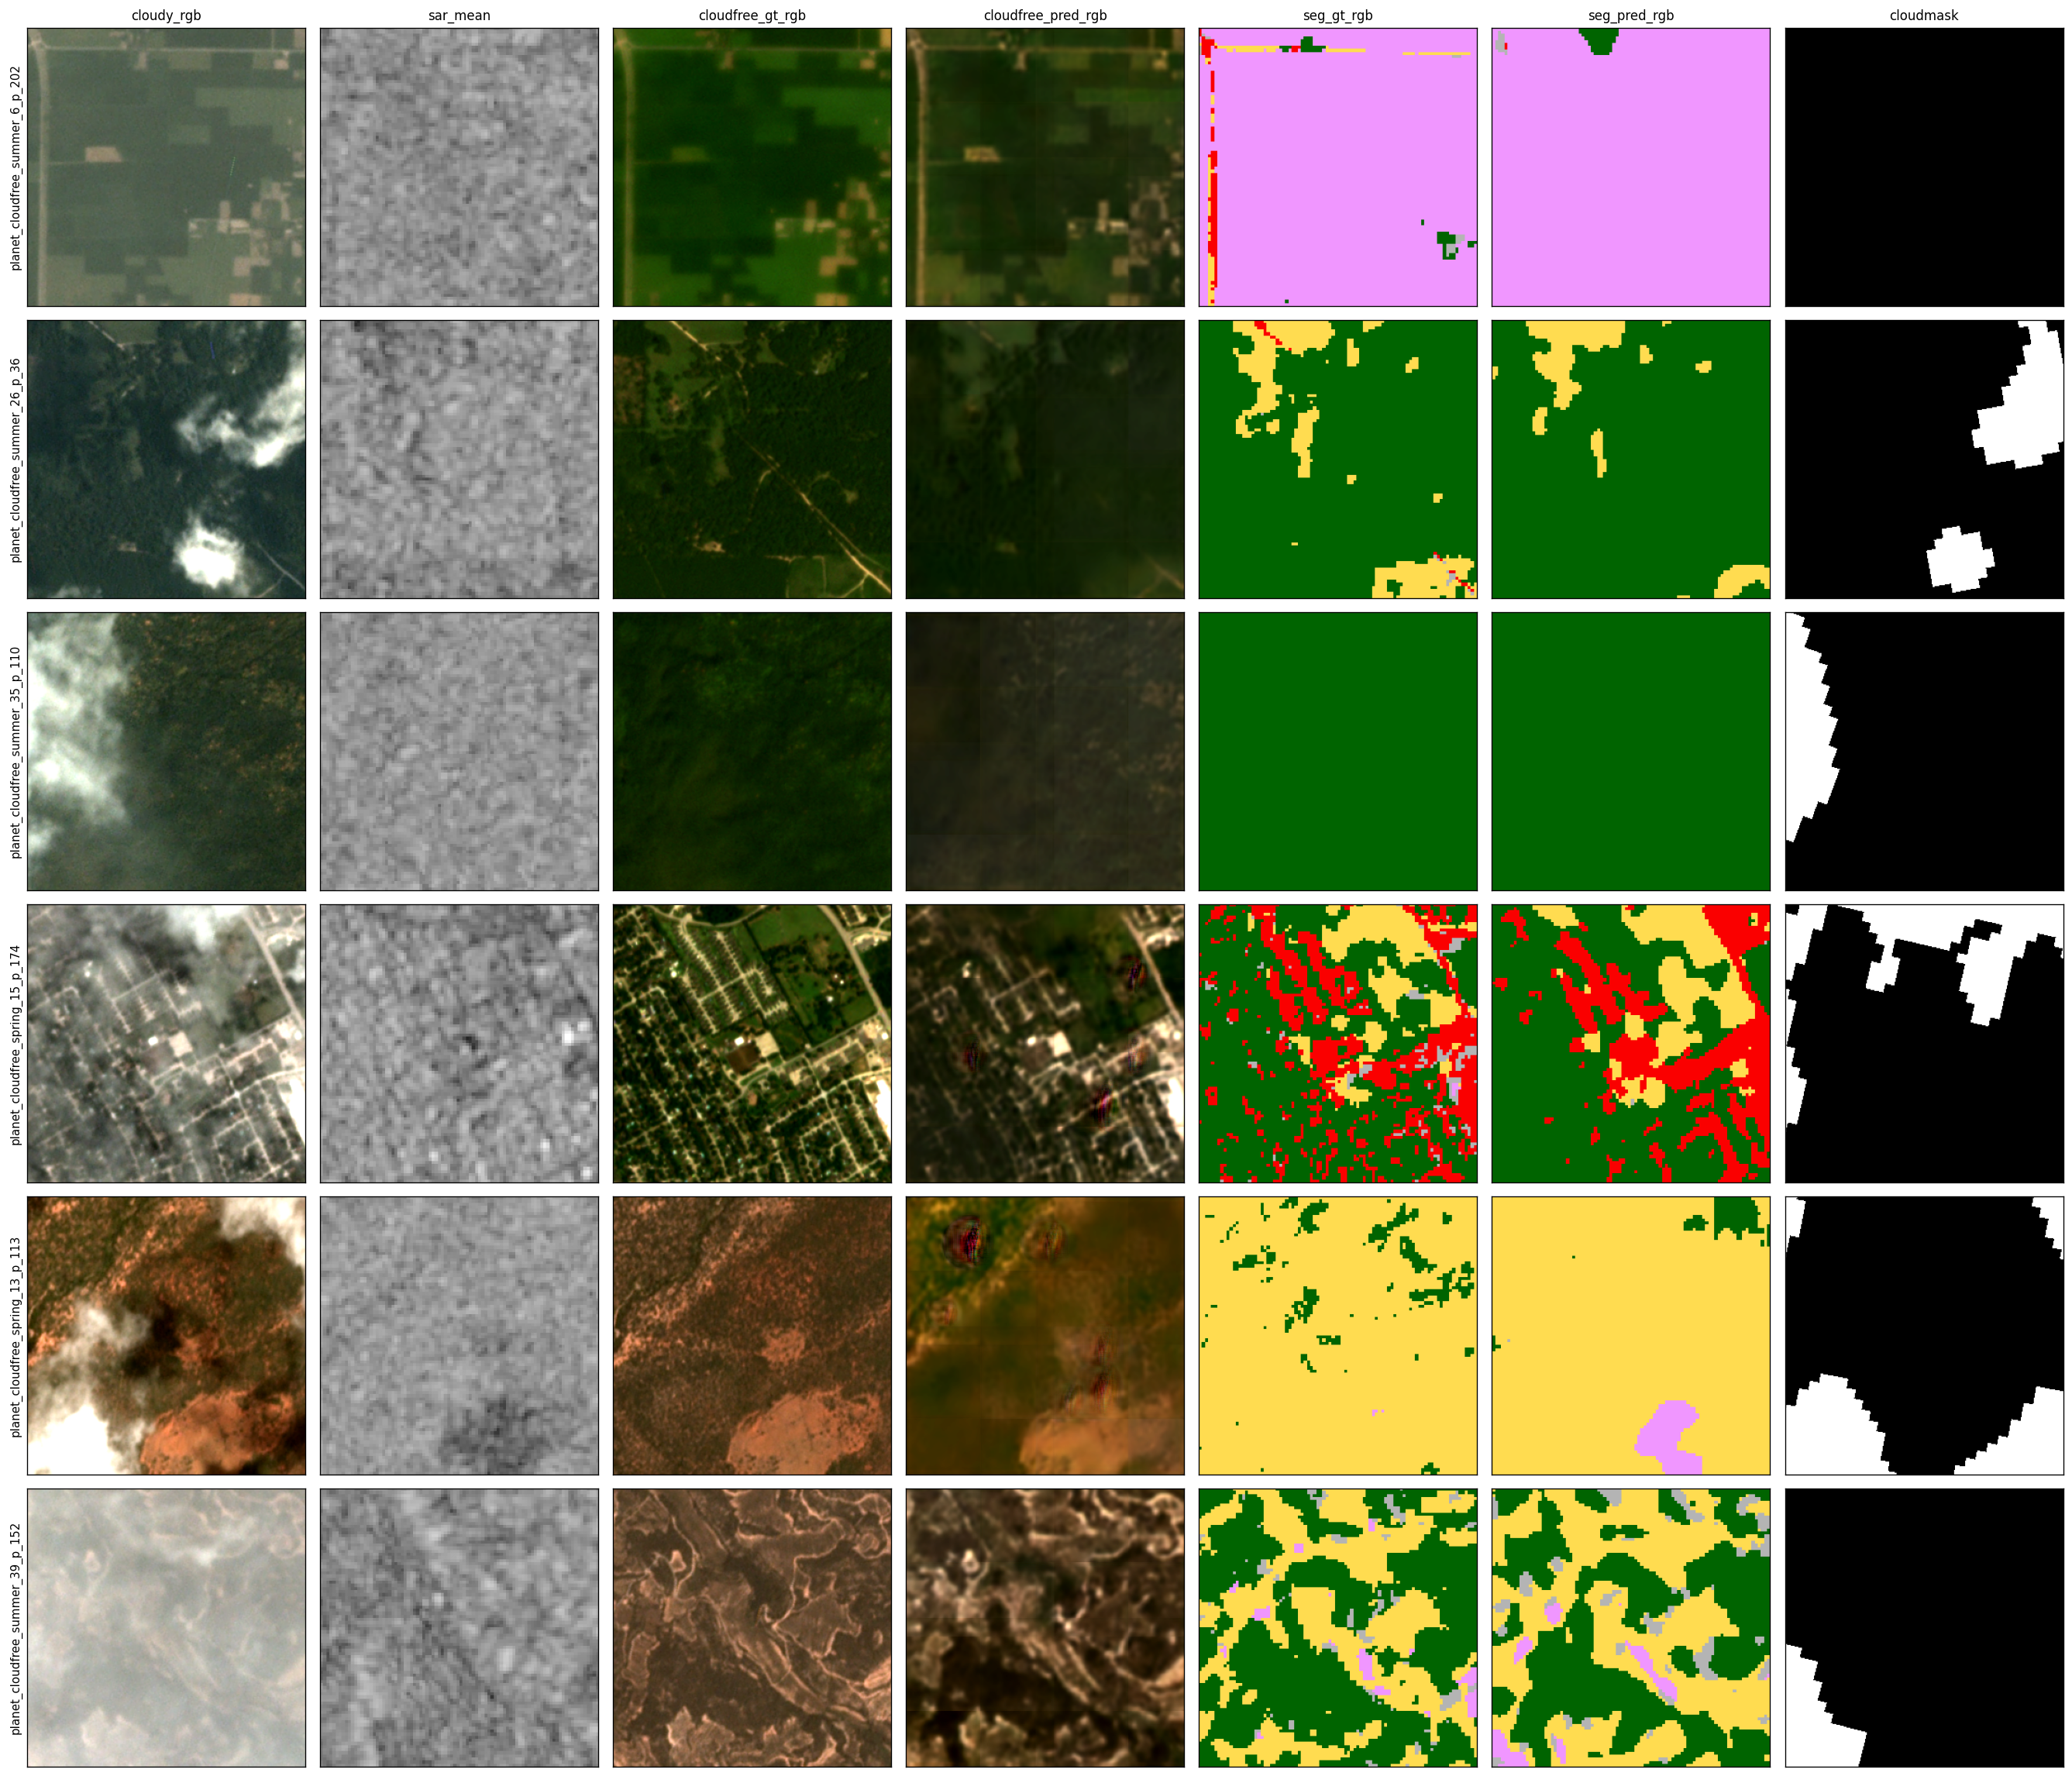

In [5]:
cfg = load_export_config(EXPORT_ROOT)
manifest_rows = load_manifest(EXPORT_ROOT)
selected_rows = choose_rows(manifest_rows, max_samples=MAX_SAMPLES, shuffle=SHUFFLE, seed=SEED)
dataset = make_dataset(cfg, selected_rows)
palette, ignore_color = test_joint_module.get_segmentation_palette(build_dataset_opts(cfg), int(cfg["num_classes"]))

rendered_samples = [render_sample(dataset[idx], EXPORT_ROOT, palette, ignore_color) for idx in range(len(dataset))]

print(f"Selected {len(selected_rows)} samples out of {len(manifest_rows)} total")
print(f"Optical brightness={OPTICAL_BRIGHTNESS}, contrast={OPTICAL_CONTRAST}")
visualize_samples(rendered_samples, DISPLAY_GROUPS);